Implementing the Perceptron Algorithm using PySpark in Google Colab

 Overview

You will implement the **Perceptron algorithm** using **PySpark** within Google Colab to develop a scalable binary classification system. The objective is to classify emails as either **spam** or **ham (not spam)** based on their text content.

You will work with an email dataset (`emails.csv`) containing raw email text and a binary spam label. You will construct a Spark-based machine learning workflow that:

1. Loads structured data into a Spark DataFrame
2. Prepares feature vectors from raw text (tokenisation, stop-word removal, TF-IDF)
3. Applies feature scaling where appropriate
4. Implements the **Perceptron learning algorithm manually**, iteratively updating model weights based on classification errors (rather than using Spark ML's built-in classifier)
5. Evaluates the model using **accuracy, precision, recall, and F1-score**
6. Analyses performance using a **confusion matrix**
7. Investigates how different **training parameters** (learning rate, number of epochs) influence predictive performance

This provides practical insight into one of the earliest and most fundamental supervised learning algorithms for binary classification, while demonstrating how PySpark can process data — and distribute a training loop — at scale.

In [1]:

!pip install -q pyspark


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

from pyspark.ml.feature import (
    RegexTokenizer,
    StopWordsRemover,
    CountVectorizer,
    IDF,
    StandardScaler,
)
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml import Pipeline

sns.set_style("whitegrid")


In [3]:
spark = SparkSession.builder \
    .appName("PerceptronSpamClassifier") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark


In [5]:

from google.colab import files
uploaded = files.upload()

DATA_PATH = "emails.csv"  # update path if needed

df = spark.read.csv(DATA_PATH, header=True, inferSchema=True, multiLine=True, escape='"')
df = df.select(
    F.col("text").cast("string").alias("text"),
    F.col("spam").cast("int").alias("label"),
)
df = df.dropna(subset=["text", "label"])

print(f"Total records: {df.count()}")
df.show(5, truncate=80)


Saving emails.csv to emails.csv
Total records: 5728
+--------------------------------------------------------------------------------+-----+
|                                                                            text|label|
+--------------------------------------------------------------------------------+-----+
|Subject: naturally irresistible your corporate identity  lt is really hard to...|    1|
|Subject: the stock trading gunslinger  fanny is merrill but muzo not colza at...|    1|
|Subject: unbelievable new homes made easy  im wanting to show you this  homeo...|    1|
|Subject: 4 color printing special  request additional information now ! click...|    1|
|Subject: do not have money , get software cds from here !  software compatibi...|    1|
+--------------------------------------------------------------------------------+-----+
only showing top 5 rows


   label  count class
0      1   1368  Spam
1      0   4360   Ham


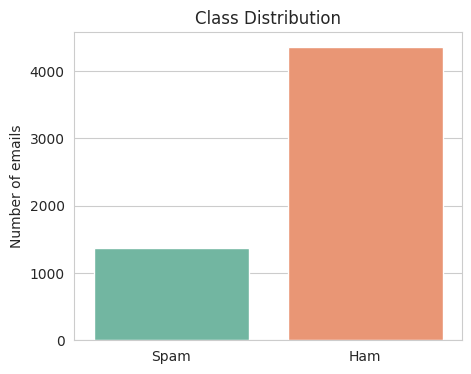

In [6]:
class_counts = df.groupBy("label").count().toPandas()
class_counts["class"] = class_counts["label"].map({0: "Ham", 1: "Spam"})
print(class_counts)

plt.figure(figsize=(5, 4))
sns.barplot(data=class_counts, x="class", y="count", hue="class", palette="Set2", legend=False)
plt.title("Class Distribution")
plt.ylabel("Number of emails")
plt.xlabel("")
plt.show()


In [7]:
VOCAB_SIZE = 1000  # cap vocabulary size to keep the manual Perceptron step tractable

tokenizer = RegexTokenizer(inputCol="text", outputCol="tokens", pattern="\\W+", toLowercase=True)
remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
count_vec = CountVectorizer(inputCol="filtered_tokens", outputCol="raw_features", vocabSize=VOCAB_SIZE, minDF=2.0)
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")

prep_pipeline = Pipeline(stages=[tokenizer, remover, count_vec, idf])
prep_model = prep_pipeline.fit(df)
featurized_df = prep_model.transform(df)

featurized_df.select("label", "tfidf_features").show(5, truncate=60)


+-----+------------------------------------------------------------+
|label|                                              tfidf_features|
+-----+------------------------------------------------------------+
|    1|(1000,[0,3,25,32,50,58,59,64,65,85,94,98,101,137,147,166,...|
|    1|(1000,[3,24,29,123,403,421,641],[0.0,1.5352800699432447,3...|
|    1|(1000,[3,13,18,23,26,85,115,124,126,167,188,201,206,216,2...|
|    1|(1000,[3,6,25,27,41,43,52,112,118,132,133,178,262,301,305...|
|    1|(1000,[3,33,74,110,165,175,183,524,685],[0.0,1.4901238835...|
+-----+------------------------------------------------------------+
only showing top 5 rows


In [8]:
scaler = StandardScaler(inputCol="tfidf_features", outputCol="scaled_features", withMean=False, withStd=True)
scaler_model = scaler.fit(featurized_df)
scaled_df = scaler_model.transform(featurized_df)

scaled_df.select("label", "scaled_features").show(5, truncate=60)


+-----+------------------------------------------------------------+
|label|                                             scaled_features|
+-----+------------------------------------------------------------+
|    1|(1000,[0,3,25,32,50,58,59,64,65,85,94,98,101,137,147,166,...|
|    1|(1000,[3,24,29,123,403,421,641],[0.0,0.8678507740484984,4...|
|    1|(1000,[3,13,18,23,26,85,115,124,126,167,188,201,206,216,2...|
|    1|(1000,[3,6,25,27,41,43,52,112,118,132,133,178,262,301,305...|
|    1|(1000,[3,33,74,110,165,175,183,524,685],[0.0,0.9660492519...|
+-----+------------------------------------------------------------+
only showing top 5 rows


In [9]:
train_df, test_df = scaled_df.randomSplit([0.8, 0.2], seed=42)
train_df = train_df.cache()
test_df = test_df.cache()

print(f"Training records: {train_df.count()}")
print(f"Test records: {test_df.count()}")


Training records: 4630
Test records: 1098


In [10]:
def to_dense_labeled_rdd(spark_df):
    """Convert a Spark DataFrame with (label, scaled_features) into an RDD of
    (numpy_dense_features, perceptron_label) where perceptron_label is -1/+1."""
    def row_to_tuple(row):
        dense = np.array(row["scaled_features"].toArray(), dtype=np.float64)
        y = 1.0 if row["label"] == 1 else -1.0
        return (dense, y)
    return spark_df.rdd.map(row_to_tuple)


class SparkPerceptron:
    """A manually implemented, distributed Perceptron classifier for PySpark."""

    def __init__(self, n_features, learning_rate=1.0, n_epochs=20, seed=42):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        rng = np.random.default_rng(seed)
        self.weights = np.zeros(n_features, dtype=np.float64)
        self.bias = 0.0
        self.history = []  # misclassification count per epoch

    def _epoch_update(self, rdd, sc):
        w_bc = sc.broadcast(self.weights)
        b_bc = self.bias

        def seq_op(acc, row):
            x, y = row
            w = w_bc.value
            pred = 1.0 if (np.dot(w, x) + b_bc) >= 0 else -1.0
            grad_w, grad_b, n_errors = acc
            if pred != y:
                grad_w = grad_w + y * x
                grad_b = grad_b + y
                n_errors += 1
            return (grad_w, grad_b, n_errors)

        def comb_op(acc1, acc2):
            return (acc1[0] + acc2[0], acc1[1] + acc2[1], acc1[2] + acc2[2])

        zero = (np.zeros_like(self.weights), 0.0, 0)
        grad_w, grad_b, n_errors = rdd.treeAggregate(zero, seq_op, comb_op, depth=3)
        w_bc.destroy()
        return grad_w, grad_b, n_errors

    def fit(self, rdd, sc, verbose=True):
        rdd = rdd.cache()
        n_train = rdd.count()
        for epoch in range(1, self.n_epochs + 1):
            grad_w, grad_b, n_errors = self._epoch_update(rdd, sc)
            self.weights = self.weights + self.learning_rate * grad_w
            self.bias = self.bias + self.learning_rate * grad_b
            self.history.append(n_errors)
            if verbose:
                print(f"Epoch {epoch:2d}/{self.n_epochs} | misclassified: {n_errors:5d} / {n_train} "
                      f"({100 * n_errors / n_train:5.2f}%)")
            if n_errors == 0:
                if verbose:
                    print("Converged: training data is linearly separable under current features.")
                break
        return self

    def predict_rdd(self, rdd):
        w = self.weights
        b = self.bias
        return rdd.map(lambda row: (row[1], 1.0 if (np.dot(w, row[0]) + b) >= 0 else -1.0))


In [11]:
sc = spark.sparkContext

train_rdd = to_dense_labeled_rdd(train_df)
test_rdd = to_dense_labeled_rdd(test_df)

n_features = VOCAB_SIZE

start = time.time()
model = SparkPerceptron(n_features=n_features, learning_rate=1.0, n_epochs=20, seed=42)
model.fit(train_rdd, sc)
print(f"Training time: {time.time() - start:.1f}s")


Epoch  1/20 | misclassified:  3518 / 4630 (75.98%)
Epoch  2/20 | misclassified:  1112 / 4630 (24.02%)
Epoch  3/20 | misclassified:  1110 / 4630 (23.97%)
Epoch  4/20 | misclassified:   611 / 4630 (13.20%)
Epoch  5/20 | misclassified:   235 / 4630 ( 5.08%)
Epoch  6/20 | misclassified:   199 / 4630 ( 4.30%)
Epoch  7/20 | misclassified:   170 / 4630 ( 3.67%)
Epoch  8/20 | misclassified:   160 / 4630 ( 3.46%)
Epoch  9/20 | misclassified:   138 / 4630 ( 2.98%)
Epoch 10/20 | misclassified:   133 / 4630 ( 2.87%)
Epoch 11/20 | misclassified:   125 / 4630 ( 2.70%)
Epoch 12/20 | misclassified:   120 / 4630 ( 2.59%)
Epoch 13/20 | misclassified:   110 / 4630 ( 2.38%)
Epoch 14/20 | misclassified:   102 / 4630 ( 2.20%)
Epoch 15/20 | misclassified:    95 / 4630 ( 2.05%)
Epoch 16/20 | misclassified:    88 / 4630 ( 1.90%)
Epoch 17/20 | misclassified:    86 / 4630 ( 1.86%)
Epoch 18/20 | misclassified:    81 / 4630 ( 1.75%)
Epoch 19/20 | misclassified:    77 / 4630 ( 1.66%)
Epoch 20/20 | misclassified:   

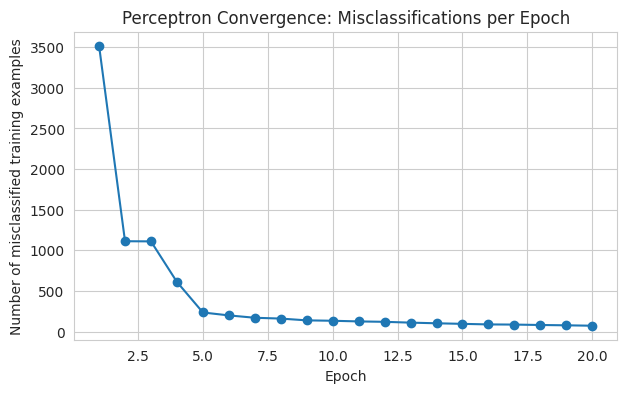

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(model.history) + 1), model.history, marker="o")
plt.title("Perceptron Convergence: Misclassifications per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of misclassified training examples")
plt.grid(True)
plt.show()


In [13]:
def evaluate(model, rdd):
    preds = model.predict_rdd(rdd).collect()
    y_true = np.array([p[0] for p in preds])
    y_pred = np.array([p[1] for p in preds])

    tp = int(np.sum((y_true == 1) & (y_pred == 1)))
    tn = int(np.sum((y_true == -1) & (y_pred == -1)))
    fp = int(np.sum((y_true == -1) & (y_pred == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred == -1)))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": np.array([[tn, fp], [fn, tp]]),  # rows: actual [ham, spam], cols: predicted [ham, spam]
    }


results = evaluate(model, test_rdd)

print(f"Accuracy:  {results['accuracy']:.4f}")
print(f"Precision: {results['precision']:.4f}")
print(f"Recall:    {results['recall']:.4f}")
print(f"F1-score:  {results['f1']:.4f}")


Accuracy:  0.9791
Precision: 0.9755
Recall:    0.9336
F1-score:  0.9541


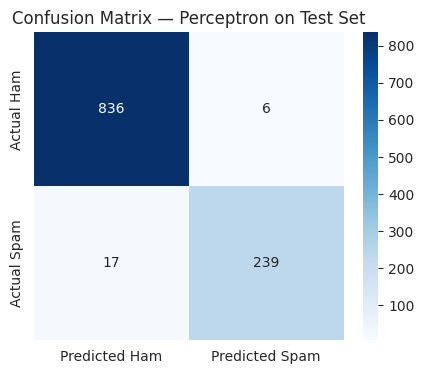

In [14]:
cm = results["confusion_matrix"]
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Ham", "Predicted Spam"],
            yticklabels=["Actual Ham", "Actual Spam"])
plt.title("Confusion Matrix — Perceptron on Test Set")
plt.show()


In [15]:
learning_rates = [0.1, 0.5, 1.0, 2.0]
n_epochs_fixed = 15

param_results = []
for lr in learning_rates:
    m = SparkPerceptron(n_features=n_features, learning_rate=lr, n_epochs=n_epochs_fixed, seed=42)
    m.fit(train_rdd, sc, verbose=False)
    res = evaluate(m, test_rdd)
    param_results.append({
        "learning_rate": lr,
        "epochs_run": len(m.history),
        "final_train_errors": m.history[-1],
        "accuracy": res["accuracy"],
        "precision": res["precision"],
        "recall": res["recall"],
        "f1": res["f1"],
    })

param_df = pd.DataFrame(param_results)
param_df


,learning_rate,epochs_run,final_train_errors,accuracy,precision,recall,f1
0,0.1,15,95,0.974499,0.971074,0.917969,0.943775
1,0.5,15,95,0.974499,0.971074,0.917969,0.943775
2,1.0,15,95,0.974499,0.971074,0.917969,0.943775
3,2.0,15,95,0.974499,0.971074,0.917969,0.943775


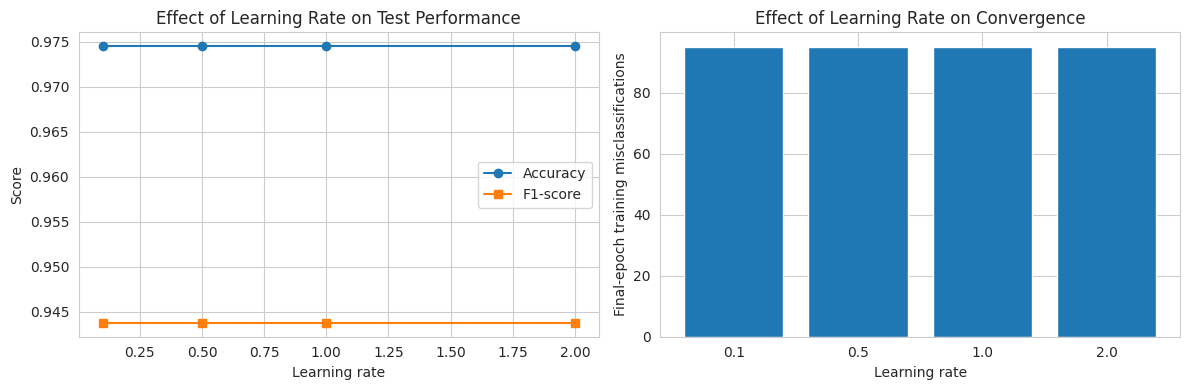

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(param_df["learning_rate"], param_df["accuracy"], marker="o", label="Accuracy")
axes[0].plot(param_df["learning_rate"], param_df["f1"], marker="s", label="F1-score")
axes[0].set_xlabel("Learning rate")
axes[0].set_ylabel("Score")
axes[0].set_title("Effect of Learning Rate on Test Performance")
axes[0].legend()
axes[0].grid(True)

axes[1].bar(param_df["learning_rate"].astype(str), param_df["final_train_errors"])
axes[1].set_xlabel("Learning rate")
axes[1].set_ylabel("Final-epoch training misclassifications")
axes[1].set_title("Effect of Learning Rate on Convergence")

plt.tight_layout()
plt.show()
